<a href="https://colab.research.google.com/github/diegogr98/Diego-Gutierrez-Astronomy/blob/main/uncertainty_quantification_mcmc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Autor:** Diego Gutiérrez

**Objetivo:** Desarrollar y validar un pipeline completo de inferencia estadística para la estimación de parámetros en modelos no lineales, combinando métodos frecuentistas y bayesianos, con análisis de incertidumbre y validación mediante simulaciones Monte Carlo.



##*Punto 1: Generación de datos sintéticos a partir de parámetros conocidos realizando un ajuste por mínimos cuadrados y recuperando los parámetros iniciales*

In [ ]:
!pip install -Uq emcee corner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import odeint
from scipy.optimize import curve_fit
from scipy.stats import kstest, norm
import emcee

In [ ]:
# Semilla para reproducibilidad
rng = np.random.default_rng(250)

# Definiendo 14 valores de x igualmente espaciados en [0.5, 5.0]
x = np.linspace(0.5, 5.0, 14)

# Modelo verdadero
y_true = 1.5 / x + 0.5

# Ruido gaussiano con sigma=0.1
sigma = 0.1
y_obs = y_true + rng.normal(0, sigma, size=len(x))

# Guardar en un DataFrame
datos = pd.DataFrame({
    "x": x,
    "y_obs": y_obs,
    "sigma": np.full_like(x, sigma, dtype=float),
    "y_true": y_true
})

print("Datos generados:")
print(datos)


Datos generados:
           x     y_obs  sigma    y_true
0   0.500000  3.410232    0.1  3.500000
1   0.846154  2.222816    0.1  2.272727
2   1.192308  1.672629    0.1  1.758065
3   1.538462  1.267635    0.1  1.475000
4   1.884615  1.323853    0.1  1.295918
5   2.230769  1.265417    0.1  1.172414
6   2.576923  1.136297    0.1  1.082090
7   2.923077  0.948183    0.1  1.013158
8   3.269231  1.024686    0.1  0.958824
9   3.615385  0.778099    0.1  0.914894
10  3.961538  0.851726    0.1  0.878641
11  4.307692  0.860841    0.1  0.848214
12  4.653846  0.804046    0.1  0.822314
13  5.000000  0.742574    0.1  0.800000


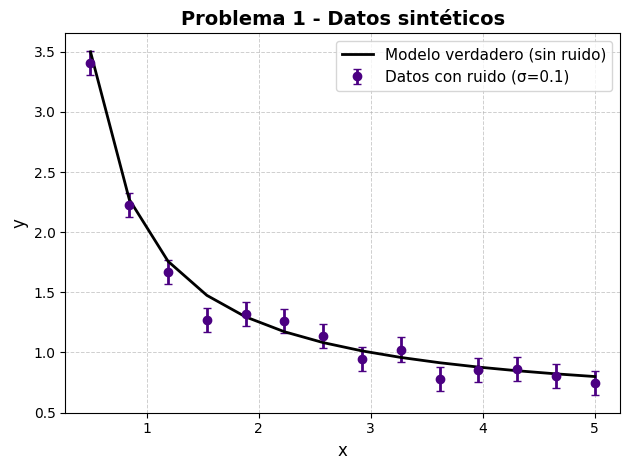

In [ ]:
# Puntos experimentales con barras de error
plt.errorbar(x, y_obs, yerr=sigma, fmt='o', color='indigo',
             elinewidth=2, capsize=3,
             markersize=6, label="Datos con ruido (σ=0.1)")

# Curva del modelo verdadero
plt.plot(x, y_true, '-', color='k', linewidth=2,
         label="Modelo verdadero (sin ruido)")

# Personalización
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.title("Problema 1 - Datos sintéticos", fontsize=14, fontweight="bold")
plt.grid(True, which="both", linestyle="--", linewidth=0.7, alpha=0.6)
plt.legend(fontsize=11, loc="best")
plt.tight_layout()
plt.show()

In [ ]:
# Definimos el modelo
def modelo(x, a, b, c):
    return a * x**b + c

# Ajuste por mínimos cuadrados con estimaciones iniciales
p0 = [1.5, -1.0, 0.5]  # valores cercanos a los reales
popt, pcov = curve_fit(modelo, x, y_obs, sigma=np.full_like(x, sigma),
                       absolute_sigma=True, p0=p0)

# Parámetros ajustados y sus errores
a_fit, b_fit, c_fit = popt
err_a, err_b, err_c = np.sqrt(np.diag(pcov))

print("Resultados del ajuste:")
print(f"a = {a_fit:.4f} ± {err_a:.4f}")
print(f"b = {b_fit:.4f} ± {err_b:.4f}")
print(f"c = {c_fit:.4f} ± {err_c:.4f}")


Resultados del ajuste:
a = 1.4218 ± 0.1660
b = -1.0237 ± 0.1253
c = 0.5149 ± 0.1224


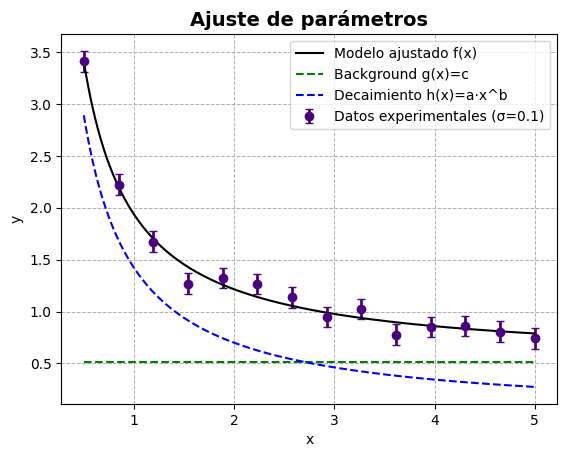

In [ ]:
# Graficar ajuste y componentes
x_dense = np.linspace(0.5, 5.0, 200)
f_fit = modelo(x_dense, *popt)
g_background = np.full_like(x_dense, c_fit)
h_decay = a_fit * x_dense**b_fit

plt.errorbar(x, y_obs, yerr=sigma, fmt='o', color='indigo',
             elinewidth=2, capsize=3,
             markersize=6, label="Datos experimentales (σ=0.1)")
plt.plot(x_dense, f_fit, color='black', label="Modelo ajustado f(x)")
plt.plot(x_dense, g_background, 'g--', label="Background g(x)=c")
plt.plot(x_dense, h_decay, 'b--', label="Decaimiento h(x)=a·x^b")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Ajuste de parámetros", fontsize=14, fontweight="bold")
plt.grid(True, which="both", linestyle="--", linewidth=0.7)
plt.legend()
plt.show()

In [ ]:
# Intervalos de confianza 95%
z95 = norm.ppf(0.985)  # 1.96

intervalos = {
    "a": (a_fit - z95*err_a, a_fit + z95*err_a),
    "b": (b_fit - z95*err_b, b_fit + z95*err_b),
    "c": (c_fit - z95*err_c, c_fit + z95*err_c)
}

print("Intervalos de confianza al 95%:")
for param, (low, high) in intervalos.items():
    print(f"{param}: {low:.4f}  ≤ {param} ≤  {high:.4f}")

Intervalos de confianza al 95%:
a: 1.0615  ≤ a ≤  1.7820
b: -1.2956  ≤ b ≤  -0.7518
c: 0.2492  ≤ c ≤  0.7805


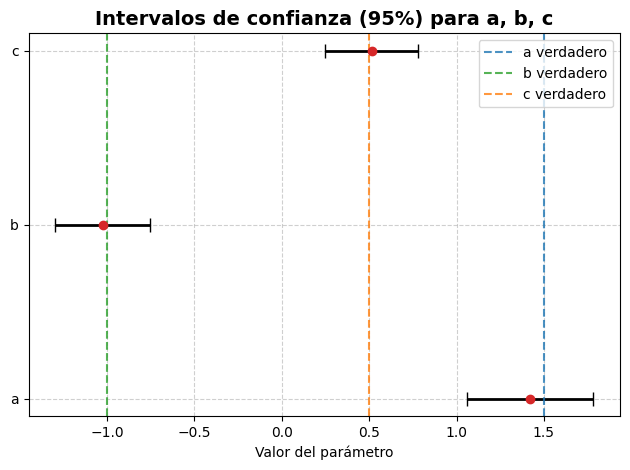

In [ ]:
# Valores ajustados y sus intervalos
parametros = ["a", "b", "c"]
valores = [a_fit, b_fit, c_fit]
errores = [err_a, err_b, err_c]

# Intervalos 95%
low = [intervalos[p][0] for p in parametros]
high = [intervalos[p][1] for p in parametros]

# Gráfico tipo forest plot
plt.errorbar(valores, parametros,
             xerr=[np.array(valores)-np.array(low),
                   np.array(high)-np.array(valores)],
             fmt='o', color='tab:red', ecolor='black',
             elinewidth=2, capsize=5)

# Añadir valores verdaderos como líneas verticales de referencia
plt.axvline(1.5, color="tab:blue", linestyle="--",
            alpha=0.8, label="a verdadero")
plt.axvline(-1.0, color="tab:green", linestyle="--",
            alpha=0.8, label="b verdadero")
plt.axvline(0.5, color="tab:orange", linestyle="--",
            alpha=0.8, label="c verdadero")

plt.xlabel("Valor del parámetro")
plt.title("Intervalos de confianza (95%) para a, b, c",
          fontsize=14, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Residuos normalizados
residuos = (y_obs - modelo(x, *popt)) / sigma

# Prueba KS contra distribución normal estándar
stat, p_value = kstest(residuos, 'norm')

print("KS statistic:", stat)
print("p-value:", p_value)

KS statistic: 0.17988254479337956
p-value: 0.6912528944697458


##*Punto 2: utilizar técnicas de Monte Carlo para estimar la distribución posterior de los parámetros, analizar correlaciones y calcular la matriz de covarianza.*

In [ ]:
def modelo2(x):
    return 1.5 * x** (-1) + 0.5

# Número de realizaciones y puntos por dataset
N_MC = 1000
N_pts = 6

# Guardando todos los datasets en una lista
datasets = []

for r in range(N_MC):
    # x uniformes en [0.5,5]
    xk = rng.uniform(0.5, 5.0, size=N_pts)
    y_true2 = modelo2(xk)
    y_obs2 = y_true2 + rng.normal(0, sigma, size=N_pts)

    df_r = pd.DataFrame({
        "realizacion": r,
        "x": xk,
        "y_true2": y_true2,
        "y_obs2": y_obs2
    })
    datasets.append(df_r)

# Unir todos los datasets en un solo DataFrame
df_all = pd.concat(datasets, ignore_index=True)
df_all.head(5)

,realizacion,x,y_true2,y_obs2
0,0,2.992905,1.001185,1.085402
1,0,2.882604,1.020363,1.039810
2,0,0.718726,2.587025,2.636270
3,0,2.647857,1.066496,1.073418
4,0,3.807928,0.893915,0.875397


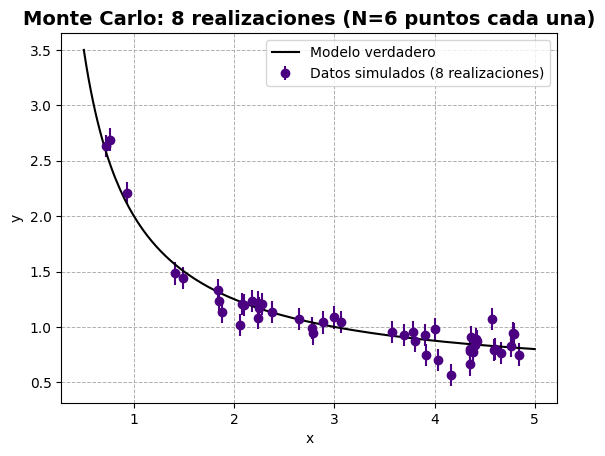

In [ ]:
# Filtrar las 8 primeras realizaciones para visualización
df_sel = df_all[df_all["realizacion"] < 8]

# Graficar todos los puntos observados con ruido
plt.errorbar(df_sel["x"], df_sel["y_obs2"], yerr=sigma, fmt='o',
             color='indigo', label="Datos simulados (8 realizaciones)")

# Curva del modelo verdadero
x_dense = np.linspace(0.5, 5.0, 200)
plt.plot(x_dense, modelo2(x_dense), '-',
         color='black', label="Modelo verdadero")

# Estilo de la figura
plt.title("Monte Carlo: 8 realizaciones (N=6 puntos cada una)",
          fontsize=14, fontweight="bold")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, which="both", linestyle="--", linewidth=0.7)
plt.legend()
plt.show()

In [ ]:
# Datos de ejemplo tomando la primera realización
df_r = df_all[df_all["realizacion"]==0]
x, y = df_r["x"].values, df_r["y_obs2"].values
yerr = np.full_like(x, 0.1, dtype=float)


# Priors uniformes simples
def log_prior(theta):
    a,b,c = theta
    if 0<a<10 and -3<b<3 and -1<c<2: return 0.0
    return -np.inf

def log_likelihood(theta,x,y,yerr):
    a,b,c = theta
    m = modelo(x,a,b,c)
    return -0.5*np.sum(((y-m)/yerr)**2 + np.log(2*np.pi*yerr**2))

def log_post(theta,x,y,yerr):
    lp = log_prior(theta)
    return lp + log_likelihood(theta,x,y,yerr) if np.isfinite(lp) else -np.inf

In [ ]:
# Configuración para la generación de MCMC
ndim, nwalkers, nsteps = 3, 24, 800
nburn, thin = 250, 5
yerr = 0.1
p0 = np.array([1.5,-1.0,0.5]) + 1e-2*np.random.randn(nwalkers,ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_post, args=(x,y,yerr))
sampler.run_mcmc(p0, nsteps, progress=True);

# Cadenas planas descartando burn-in
flat = sampler.get_chain(discard=500, thin=10, flat=True)

# Estimadores
medianas = np.median(flat,axis=0)
stds = np.std(flat,axis=0)
print("Resultados posteriores:")
print(f"a = {medianas[0]:.3f} ± {stds[0]:.3f}")
print(f"b = {medianas[1]:.3f} ± {stds[1]:.3f}")
print(f"c = {medianas[2]:.3f} ± {stds[2]:.3f}")

100%|██████████| 800/800 [00:03<00:00, 223.75it/s]

Resultados posteriores:
a = 1.791 ± 0.721
b = -0.797 ± 0.645
c = 0.286 ± 0.584


In [ ]:
results = []
for r in range(N_MC):   # todas las realizaciones
    dfr = df_all[df_all["realizacion"]==r]
    x, y = dfr["x"].values, dfr["y_obs2"].values

    # inicialización cerca de los valores verdaderos
    p0 = np.array([1.5,-1.0,0.5]) + 1e-2*np.random.randn(nwalkers,ndim)

    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_post, args=(x,y,yerr))
    sampler.run_mcmc(p0, nsteps, progress=False)

    flat = sampler.get_chain(discard=nburn, thin=thin, flat=True)
    a_med,b_med,c_med = np.median(flat,axis=0)
    results.append({"realizacion":r,"a_med":a_med,"b_med":b_med,"c_med":c_med})

df_results = pd.DataFrame(results)
print(df_results.head())

   realizacion     a_med     b_med     c_med
0            0  1.482855 -1.033159  0.546671
1            1  1.253714 -1.573979  0.749072
2            2  2.248311 -2.107752  0.765146
3            3  1.445942 -1.734586  0.751639
4            4  2.821331 -2.039441  0.623867


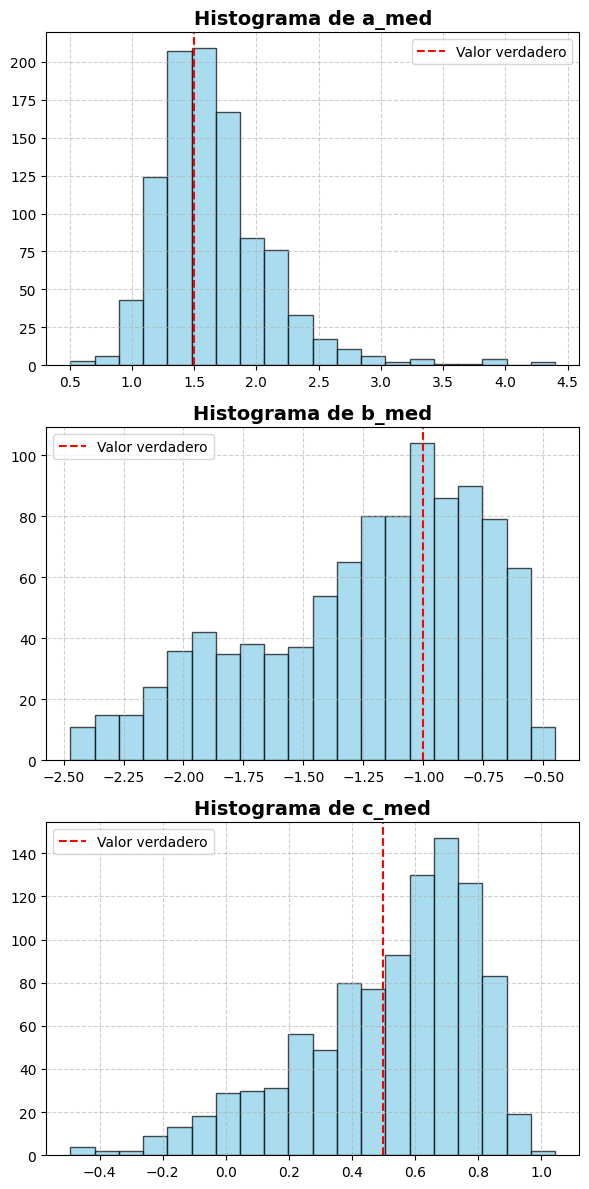

In [ ]:
params = ["a_med","b_med","c_med"]
verdaderos = [1.5, -1.0, 0.5]

fig, axs = plt.subplots(3, 1, figsize=(6,12))

for i, p in enumerate(params):
    axs[i].hist(df_results[p], bins=20, color="skyblue", edgecolor="k", alpha=0.7)
    axs[i].axvline(verdaderos[i], color="red", linestyle="--", label="Valor verdadero")
    axs[i].set_title(f"Histograma de {p}",
          fontsize=14, fontweight="bold")
    axs[i].grid(True, linestyle="--", alpha=0.6)
    axs[i].legend()

plt.tight_layout()
plt.show()

In [ ]:
#Valores finales después de las 1000 realizaciones
print("Estadísticos globales después de 1000 realizaciones ")
mean_a, mean_b, mean_c = df_results[["a_med","b_med","c_med"]].mean()
std_a, std_b, std_c = df_results[["a_med","b_med","c_med"]].std()

# Imprimiendo los valores del promedio y su desviación estándar
print(f"a = {mean_a:.3f} ± {std_a:.3f}")
print(f"b = {mean_b:.3f} ± {std_b:.3f}")
print(f"c = {mean_c:.3f} ± {std_c:.3f}")

Estadísticos globales después de 1000 realizaciones 
a = 1.657 ± 0.459
b = -1.240 ± 0.472
c = 0.517 ± 0.276


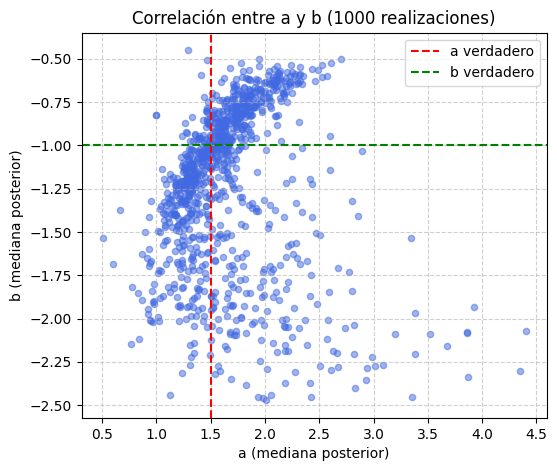

In [ ]:
# gráfica a vs b hallando posibles correlaciones
plt.figure(figsize=(6,5))
plt.scatter(df_results["a_med"],
            df_results["b_med"],
            alpha=0.5, color="royalblue", s=20)
plt.axvline(1.5, color="red", linestyle="--", label="a verdadero")
plt.axhline(-1.0, color="green", linestyle="--", label="b verdadero")
plt.xlabel("a (mediana posterior)")
plt.ylabel("b (mediana posterior)")
plt.title("Correlación entre a y b (1000 realizaciones)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


In [ ]:
# Matriz de covarianza de (a,b)
cov_ab = np.cov(df_results["a_med"], df_results["b_med"])
print("\nMatriz de covarianza de (a, b):")
print(cov_ab)

# Coeficientes de correlación
rho_ab = np.corrcoef(df_results["a_med"], df_results["b_med"])[0,1]
rho_ac = np.corrcoef(df_results["a_med"], df_results["c_med"])[0,1]
rho_bc = np.corrcoef(df_results["b_med"], df_results["c_med"])[0,1]

print("\nCoeficientes de correlación:")
print(f"ρ_ab = {rho_ab:.3f}")
print(f"ρ_ac = {rho_ac:.3f}")
print(f"ρ_bc = {rho_bc:.3f}")


Matriz de covarianza de (a, b):
[[ 0.21051395 -0.0025981 ]
 [-0.0025981   0.22295108]]

Coeficientes de correlación:
ρ_ab = -0.012
ρ_ac = -0.467
ρ_bc = -0.789
